# Diabetes Prediction Using Supervised Classification

**Assignment 2 — 100 NextGen AI Engineers, Cohort 3**

## Objective

Build and evaluate supervised classification models that predict whether a patient is diabetic from routine diagnostic measurements, and select the model best suited to a clinical screening context.

## Dataset

The Pima Indians Diabetes dataset: 768 patient records described by eight numeric diagnostic features and a binary target (`Outcome`, where 1 indicates diabetes).

## Contents

| Part | Focus |
| --- | --- |
| 1 | Data preparation — loading, exploration, missing-value treatment, train–test split |
| 2 | Model development — Logistic Regression, Decision Tree and Random Forest pipelines |
| 3 | Training and comparative evaluation |
| 4 | Final model — detailed evaluation and overfitting analysis |
| 5 | Performance analysis, limitations and improvement strategies |

## Part 1 — Data Preparation

The dataset is loaded, inspected for structure and quality, cleaned of physiologically invalid measurements, and split into training and test sets before any model is fitted.

### 1.1 Import Libraries and Load the Dataset

The analysis uses pandas and NumPy for data handling, and Matplotlib and Seaborn for visualisation.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
data = pd.read_csv("/content/diabetes.csv")

In [27]:
data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### 1.2 Explore the Dataset Structure

The shape, column names, data types and null counts are inspected to establish a baseline understanding of the data before any transformation is applied.

In [28]:
data.shape

(768, 9)

In [29]:
data.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [30]:
data.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [31]:
data.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### 1.3 Statistical Summary

Descriptive statistics for every feature. The minimum values reported below give the first indication of a data-quality issue: several columns record zeros where a zero is not physiologically possible.

In [32]:
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

### 1.4 Separate Features and Target

`Outcome` is isolated as the target variable; the remaining eight columns form the feature matrix.

In [33]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

Target:
Outcome


### 1.5 Treat Invalid Zero Values as Missing

`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` and `BMI` cannot legitimately be zero in a living patient, so these zeros represent unrecorded measurements rather than genuine readings. Replacing them with `NaN` makes the missingness explicit, so that it can be handled by a dedicated imputation step inside the modelling pipeline instead of being silently learned as a valid value.

In [34]:
zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[zero_columns] = X[zero_columns].replace(0, np.nan)

print(X.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


### 1.6 Train–Test Split

The data is divided into an 80% training partition and a 20% test partition. Stratifying on `Outcome` preserves the original class ratio in both partitions — important here, since the positive class accounts for roughly 35% of the records — and a fixed `random_state` keeps the split reproducible.

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


## Part 2 — Model Development

Three classifiers are defined, each wrapped in a scikit-learn `Pipeline`. Imputation and scaling are declared as pipeline steps rather than applied beforehand, so that every transformation is fitted on the training data alone. This prevents information from the test set leaking into the preprocessing statistics.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

### 2.1 Logistic Regression

A linear baseline. Median imputation fills the missing measurements, and standardisation places all features on a comparable scale — a practical requirement for the solver to converge reliably and for the coefficients to be interpretable.

In [37]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

### 2.2 Decision Tree

A non-linear model that captures interactions between features while remaining directly interpretable. `max_depth=5` and `min_samples_leaf=5` act as regularisation, limiting how far the tree may grow and preventing it from isolating individual training records.

In [50]:
tree_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ))
])

### 2.3 Random Forest

An ensemble of 300 depth-limited trees. Averaging many decorrelated trees generally reduces variance relative to a single tree, at the cost of direct interpretability. Tree-based models are invariant to feature scale, so no scaler is included.

In [39]:
forest_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

### 2.4 Train the Models

All three pipelines are fitted on the training partition.

In [40]:
models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(name, "trained successfully")

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


## Part 3 — Training and Evaluation

Each model is scored on accuracy, precision, recall and F1. Training and test accuracy are reported side by side so that the generalisation gap is visible for every candidate. Recall is analysed separately in Part 5, as it carries the greatest clinical weight in a screening application.

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

results = []

for name, model in models.items():

    # Training predictions
    train_pred = model.predict(X_train)

    # Testing predictions
    test_pred = model.predict(X_test)

    results.append({
        "Model": name,

        "Train Accuracy":
            accuracy_score(y_train, train_pred),

        "Test Accuracy":
            accuracy_score(y_test, test_pred),

        "Test Precision":
            precision_score(y_test, test_pred),

        "Test Recall":
            recall_score(y_test, test_pred),

        "Test F1":
            f1_score(y_test, test_pred)
    })

results_df = pd.DataFrame(results)

print(results_df)

                 Model  Train Accuracy  Test Accuracy  Test Precision  \
0  Logistic Regression        0.796417       0.707792        0.600000   
1        Decision Tree        0.801303       0.772727        0.650794   
2        Random Forest        0.863192       0.746753        0.682927   

   Test Recall   Test F1  
0     0.500000  0.545455  
1     0.759259  0.700855  
2     0.518519  0.589474  


## Part 4 — Final Model: Decision Tree

The Decision Tree is carried forward as the final model. It achieved the highest test accuracy and the highest recall of the three candidates, while showing the smallest gap between training and test performance. This section evaluates it in detail.

In [42]:
final_model = tree_model

final_model.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 DecisionTreeClassifier(max_depth=5, min_samples_leaf=5,
                                        random_state=42))])

### 4.1 Performance on the Training Set

Training accuracy establishes the reference point against which test performance is compared.

In [43]:
y_train_pred = final_model.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)

print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.8013029315960912


### 4.2 Performance on the Test Set

Test accuracy measures performance on records the model has never seen and is the primary indicator of how well it generalises.

In [44]:
y_test_pred = final_model.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)

print("Testing Accuracy:", test_accuracy)

Testing Accuracy: 0.7727272727272727


### 4.3 Precision, Recall and F1 Score

Accuracy alone is insufficient for an imbalanced medical dataset. Precision, recall and their harmonic mean (F1) describe how reliably the positive — diabetic — class is identified.

In [45]:
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.6507936507936508
Recall: 0.7592592592592593
F1 Score: 0.7008547008547008


### 4.4 Confusion Matrix

The confusion matrix decomposes the predictions into the four possible outcomes, exposing the error types that a single accuracy figure conceals.

In [46]:
cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[78 22]
 [13 41]]


### 4.5 Confusion Matrix Interpretation

| Outcome | Count | Interpretation |
| --- | --- | --- |
| True Negative (TN) | 78 | Patients without diabetes, correctly identified as non-diabetic. |
| False Positive (FP) | 22 | Patients without diabetes, incorrectly flagged as diabetic. |
| False Negative (FN) | 13 | Patients with diabetes, incorrectly cleared as non-diabetic. |
| True Positive (TP) | 41 | Patients with diabetes, correctly identified as diabetic. |

Of the two error types, the 13 false negatives are the more serious in a screening context: a false positive results in additional confirmatory testing, whereas a false negative leaves a diabetic patient undiagnosed.

### 4.6 Confusion Matrix Visualisation

The same results presented as a heat map, with the annotated counts placed in each cell.

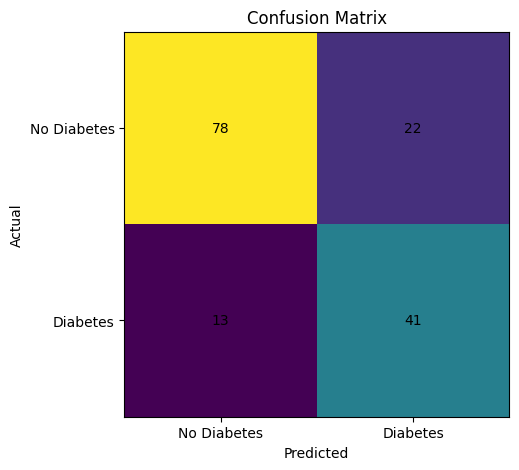

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.show()

### 4.7 Classification Report

The per-class breakdown of precision, recall and F1, together with the support count for each class.

In [51]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No Diabetes", "Diabetes"]
))

              precision    recall  f1-score   support

 No Diabetes       0.86      0.78      0.82       100
    Diabetes       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



### 4.8 Overfitting Analysis

Training and test accuracy are compared for the two tree-based models to assess how well each generalises beyond the data it was fitted on.

| Model | Training accuracy | Test accuracy | Gap |
| --- | --- | --- | --- |
| Decision Tree | 80.13% | 77.27% | 2.86 pp |
| Random Forest | 86.32% | 74.68% | 11.64 pp |

**Conclusion.** The Decision Tree's gap of under three percentage points indicates that its performance on unseen data closely tracks its performance during training; there is no evidence of severe overfitting. The Random Forest, despite the stronger training score, loses almost twelve percentage points on the test set. In this configuration it has fitted the training data considerably more closely without converting that into better generalisation, which is why the simpler and more interpretable Decision Tree is preferred as the final model.

## Part 5 — Performance Analysis and Improvement

This section identifies the metric that matters most for the problem, assesses whether the final model is fit for purpose, states its limitations honestly, and outlines concrete strategies for improving it.

### 5.1 Why Recall Is the Priority Metric

Recall answers the question that matters clinically: *of all patients who genuinely have diabetes, what proportion did the model correctly identify?*

```
Recall = TP / (TP + FN)
```

For the final Decision Tree:

```
Recall = 41 / (41 + 13) = 0.7593  →  75.93%
```

The model therefore detects approximately 76% of the diabetic patients in the test set and misses the remaining 24%.

A false negative means a patient who has diabetes is told that they do not. In a screening workflow this is materially more costly than a false positive, which merely sends a healthy patient for confirmatory testing. Judging the model on accuracy alone would obscure this asymmetry, which is why precision, recall, F1 and the confusion matrix are considered together.

### 5.2 Is the Model Performing Well?

| Metric | Score |
| --- | --- |
| Accuracy | 77.27% |
| Precision | 65.08% |
| Recall | 75.93% |
| F1 Score | 70.09% |

The model is a reasonable baseline: it identifies roughly three-quarters of the diabetic patients and generalises without severe overfitting. It is not, however, accurate enough to be treated as a reliable clinical diagnostic system. On a test set of 154 records it still produces 13 false negatives and 22 false positives, and precision of 65.08% means that approximately one in three positive predictions is a false alarm.

**Limitations**

1. **Dataset size.** With 768 records in total and 154 in the test set, individual metrics are sensitive to a small number of predictions and the dataset is modest for a healthcare prediction system.
2. **Missing measurements.** A substantial share of values were recorded as zero — 374 for `Insulin` and 227 for `SkinThickness`. Median imputation is a pragmatic treatment, but it substitutes an assumption for data that was never collected.
3. **Limited feature set.** Only eight predictors are available. Clinically relevant information such as family history, diet, physical activity, cholesterol, HbA1c, wider medical history and current medication is absent.
4. **Model variance.** A single Decision Tree is sensitive to the particular training data it sees, so a different train–test split may produce noticeably different results. Cross-validation yields a more stable estimate than a single split.
5. **Scope.** This is an educational model built on a public dataset. It has not been clinically validated and must not be used for medical diagnosis.

### 5.3 Improving the Model

**Improvement 1 — Hyperparameter tuning**

`GridSearchCV` searches combinations of `max_depth`, `min_samples_leaf` and `min_samples_split` using 5-fold cross-validation, scored on recall to reflect the priority established above.

The resulting best cross-validated recall (0.598) is not directly comparable to the 75.93% reported earlier: the cross-validated figure averages performance across five held-out folds of the training data, whereas the earlier value comes from a single test split. The lower number is the more conservative — and more trustworthy — estimate of how the model behaves on new patients.

In [49]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [3, 4, 5, 6, 8, 10],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    tree_model,
    param_grid,
    cv=5,
    scoring="recall"
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("Best CV Recall:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10}
Best CV Recall:
0.5982281284606865


**Improvement 2 — Handling class imbalance**

| Class | Records | Share |
| --- | --- | --- |
| No Diabetes (0) | 500 | 65.1% |
| Diabetes (1) | 268 | 34.9% |

The dataset is moderately imbalanced, which biases an unweighted classifier towards the majority class and depresses recall on precisely the class of interest. Setting `class_weight="balanced"` makes the misclassification of a diabetic patient proportionally more costly during training:

```python
DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)
```

Related options include resampling the training data (for example with SMOTE) and tuning the decision threshold on predicted probabilities rather than accepting the default 0.5 cut-off.

## Conclusion

Three classification algorithms — Logistic Regression, Decision Tree and Random Forest — were implemented and compared for diabetes prediction on the Pima Indians dataset.

| Model | Test accuracy | Test precision | Test recall | Test F1 |
| --- | --- | --- | --- | --- |
| Logistic Regression | 70.78% | 60.00% | 50.00% | 54.55% |
| **Decision Tree** | **77.27%** | **65.08%** | **75.93%** | **70.09%** |
| Random Forest | 74.68% | 68.29% | 51.85% | 58.95% |

The Decision Tree delivered the strongest overall test performance and was selected as the final model. Its confusion matrix contains 78 true negatives, 22 false positives, 13 false negatives and 41 true positives, and the modest 2.86-percentage-point gap between training accuracy (80.13%) and test accuracy (77.27%) indicates that it generalises without severe overfitting. Recall is the decisive metric for this problem, because a false negative corresponds to a diabetic patient being cleared as healthy; at 75.93% the Decision Tree is well ahead of both alternatives on this measure.

The model should be regarded as a sound baseline rather than a finished system. Further gains are most likely to come from hyperparameter tuning scored on recall, explicit class-imbalance handling, feature engineering, decision-threshold calibration, and the evaluation of additional algorithms such as gradient boosting under cross-validation.